In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_curve, auc, RocCurveDisplay

import time
import mnist_reader
from modelevaluator import Evaluator
from models.knn import KNN
from models.mlp import MLP
from models.logistic import LogReg
from seed import seed

In [2]:
X_train, y_train = mnist_reader.load_mnist('dataset', kind='train')
X_test, y_test = mnist_reader.load_mnist('dataset', kind='t10k')
print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)

(60000, 784) (60000,) (10000, 784) (10000,)


In [3]:
clothing_types = {
    0: 'T-shirt/top',
    1: 'Trouser',
    2: 'Pullover',
    3: 'Dress',
    4: 'Coat',
    5: 'Sandal',
    6: 'Shirt',
    7: 'Sneaker',
    8: 'Bag',
    9: 'Ankle boot'
}

In [4]:
l = LogReg()
k = KNN()
f = MLP()

In [5]:
def timefit(model, X_train, y_train):
    start = time.time()
    model.fit(X_train, y_train)
    end = time.time()
    return end - start

Data Exploration

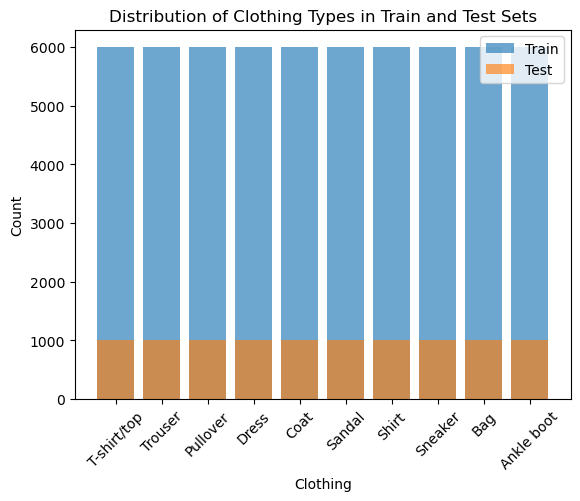

In [5]:
df_ytrain = pd.DataFrame(y_train, columns=['label'])
df_y_test = pd.DataFrame(y_test, columns=['label'])
train_labels = df_ytrain['label'].value_counts().sort_index()
test_labels = df_y_test['label'].value_counts().sort_index()
plt.bar([clothing_types[i] for i in train_labels.index], train_labels.values, alpha=0.65, label='Train')
plt.bar([clothing_types[i] for i in test_labels.index], test_labels.values, alpha=0.65, label='Test')
plt.xlabel('Clothing')
plt.ylabel('Count')
plt.title('Distribution of Clothing Types in Train and Test Sets')
plt.legend()
plt.xticks(rotation=45)
plt.show()

In [7]:
ltime = timefit(l, X_train, y_train)

Training time for Logistic Regression: 117.76 seconds


c:\Users\shubh\.conda\envs\cs178thing\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression Accuracy: 0.8339


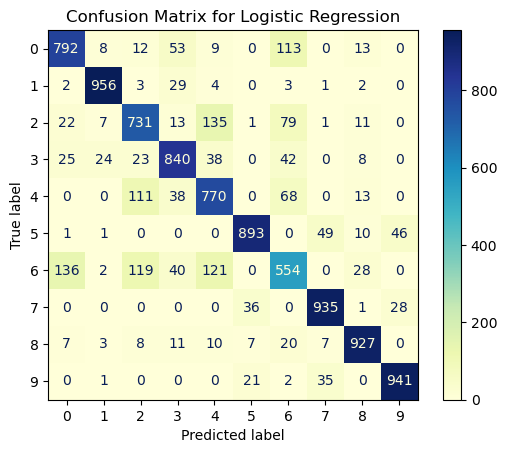

In [8]:
le = Evaluator(l, "Logistic Regression")
print(f"Training time for Logistic Regression: {ltime:.2f} seconds")
print("Logistic Regression Accuracy:", le.score(X_test, y_test))
le.cm(X_test, y_test, "YlGnBu")

kNN Accuracy: 0.8541
Evaluation time for kNN: 24.14 seconds


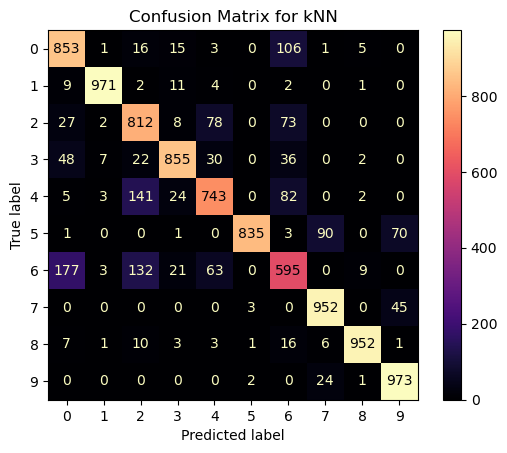

In [8]:
# Fitting datapoints on kNN is always instant, instead the model takes time to predict based on training data
k.fit(X_train, y_train)
ke = Evaluator(k, "kNN")
start = time.time()
print("kNN Accuracy:", ke.score(X_test, y_test))
end = time.time()
ktime = end - start
print(f"Evaluation time for kNN: {ktime:.2f} seconds")
ke.cm(X_test, y_test, "magma")

In [13]:
ftime = timefit(f, X_train, y_train)

Training time for MLP: 100.25 seconds
MLP Accuracy: 0.8441


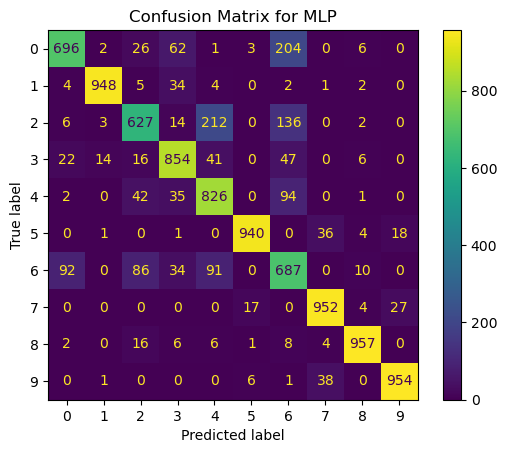

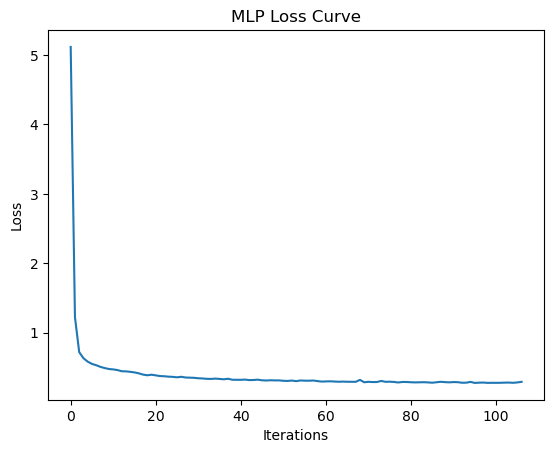

In [14]:
fe = Evaluator(f, "MLP")
print(f"Training time for MLP: {ftime:.2f} seconds")
print("MLP Accuracy:", fe.score(X_test, y_test))
fe.cm(X_test, y_test, "viridis")

plt.plot(f.classifier.loss_curve_)
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.title('MLP Loss Curve')
plt.show()

In [16]:
print(le.cm)
print(ke.cm)
print(fe.cm)

[[792   8  12  53   9   0 113   0  13   0]
 [  2 956   3  29   4   0   3   1   2   0]
 [ 22   7 731  13 135   1  79   1  11   0]
 [ 25  24  23 840  38   0  42   0   8   0]
 [  0   0 111  38 770   0  68   0  13   0]
 [  1   1   0   0   0 893   0  49  10  46]
 [136   2 119  40 121   0 554   0  28   0]
 [  0   0   0   0   0  36   0 935   1  28]
 [  7   3   8  11  10   7  20   7 927   0]
 [  0   1   0   0   0  21   2  35   0 941]]
[[853   1  16  15   3   0 106   1   5   0]
 [  9 971   2  11   4   0   2   0   1   0]
 [ 27   2 812   8  78   0  73   0   0   0]
 [ 48   7  22 855  30   0  36   0   2   0]
 [  5   3 141  24 743   0  82   0   2   0]
 [  1   0   0   1   0 835   3  90   0  70]
 [177   3 132  21  63   0 595   0   9   0]
 [  0   0   0   0   0   3   0 952   0  45]
 [  7   1  10   3   3   1  16   6 952   1]
 [  0   0   0   0   0   2   0  24   1 973]]
[[696   2  26  62   1   3 204   0   6   0]
 [  4 948   5  34   4   0   2   1   2   0]
 [  6   3 627  14 212   0 136   0   2   0]
 [ 22  14

Other accuracy metrics to consider:   
F1 Score/precision and recall, different error types (MAE, MSE), ROC curve, AUC-ROC

We can also do more visualizations/interpretations on the confusion matrices

In [ ]:
# Can we do ROC/AUC for multi-class?
